In [3]:
!pip -q install torch torchvision torchaudio
!pip -q install pandas numpy matplotlib tqdm
!pip -q install nltk bert-score sacrebleu
!pip -q install sentencepiece

In [4]:
import os
import re
import time
import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from collections import Counter

import nltk
from nltk.translate.bleu_score import corpus_bleu

from bert_score import score

warnings.filterwarnings("ignore")

nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [23]:

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

Device : cuda


In [5]:

train_sa = pd.read_csv("train_sa_10000.csv")
train_en = pd.read_csv("train_en_10000.csv")

dev_sa = pd.read_csv("dev_sa_1000.csv")
dev_en = pd.read_csv("dev_en_1000.csv")

test_sa = pd.read_csv("test_sa_1000.csv")
test_en = pd.read_csv("test_en_1000.csv")

print(train_sa.shape)
print(train_en.shape)

print(dev_sa.shape)
print(dev_en.shape)

print(test_sa.shape)
print(test_en.shape)

(10000, 2)
(10000, 2)
(1000, 2)
(1000, 2)
(1000, 2)
(1000, 2)


In [7]:
train_df = train_sa.merge(train_en, on="Source_id")

dev_df = dev_sa.merge(dev_en, on="Source_id")

test_df = test_sa.merge(test_en, on="Source_id")

print(train_df.head())

print()

print(train_df.columns)

   Source_id                                        Sentence_sa  \
0          1                         "Ctrl, S नुत्वा रक्षन्तु।"   
1          2                     गुरुः छात्रान् एकवारं पाठयति ।   
2          3  चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...   
3          4       वयं  Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।   
4          5  "अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...   

                                         Sentence_en  
0                              Save it with Ctrl, S.  
1         Teacher will teach the students only once.  
2  To recreate this animation, I have to take two...  
3    I will choose Colors options by clicking on it.  
4  "See the example here - one mountain, four vil...  

Index(['Source_id', 'Sentence_sa', 'Sentence_en'], dtype='object')


In [9]:
import string

def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r"\s+", " ", text)

    text = text.strip()

    return text


train_df["Sentence_sa"] = train_df["Sentence_sa"].apply(clean_text)
train_df["Sentence_en"] = train_df["Sentence_en"].apply(clean_text)

dev_df["Sentence_sa"] = dev_df["Sentence_sa"].apply(clean_text)
dev_df["Sentence_en"] = dev_df["Sentence_en"].apply(clean_text)

test_df["Sentence_sa"] = test_df["Sentence_sa"].apply(clean_text)
test_df["Sentence_en"] = test_df["Sentence_en"].apply(clean_text)

print(train_df.head())

   Source_id                                        Sentence_sa  \
0          1                         "ctrl, s नुत्वा रक्षन्तु।"   
1          2                     गुरुः छात्रान् एकवारं पाठयति ।   
2          3  चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...   
3          4        वयं colors विकल्पं तस्योपरि नोदनेन चिनुमः ।   
4          5  "अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...   

                                         Sentence_en  
0                              save it with ctrl, s.  
1         teacher will teach the students only once.  
2  to recreate this animation, i have to take two...  
3    i will choose colors options by clicking on it.  
4  "see the example here - one mountain, four vil...  


In [11]:


def tokenize(text):

    return text.split()


print(tokenize(train_df.iloc[0]["Sentence_sa"]))

print(tokenize(train_df.iloc[0]["Sentence_en"]))

['"ctrl,', 's', 'नुत्वा', 'रक्षन्तु।"']
['save', 'it', 'with', 'ctrl,', 's.']


In [13]:
SPECIAL_TOKENS = ["<pad>", "<sos>", "<eos>", "<unk>"]


def build_vocab(sentences, min_freq=2):

    counter = Counter()

    for sentence in sentences:

        counter.update(tokenize(sentence))

    vocab = {}

    idx2word = {}

    for token in SPECIAL_TOKENS:

        vocab[token] = len(vocab)

    for word, freq in counter.items():

        if freq >= min_freq:

            if word not in vocab:

                vocab[word] = len(vocab)

    for word, idx in vocab.items():

        idx2word[idx] = word

    return vocab, idx2word


SRC_VOCAB, SRC_IDX2WORD = build_vocab(train_df["Sentence_sa"])

TRG_VOCAB, TRG_IDX2WORD = build_vocab(train_df["Sentence_en"])

print("Source Vocabulary :", len(SRC_VOCAB))
print("Target Vocabulary :", len(TRG_VOCAB))

Source Vocabulary : 8379
Target Vocabulary : 7072


In [18]:

SRC_PAD_IDX = SRC_VOCAB["<pad>"]
SRC_SOS_IDX = SRC_VOCAB["<sos>"]
SRC_EOS_IDX = SRC_VOCAB["<eos>"]
SRC_UNK_IDX = SRC_VOCAB["<unk>"]

TRG_PAD_IDX = TRG_VOCAB["<pad>"]
TRG_SOS_IDX = TRG_VOCAB["<sos>"]
TRG_EOS_IDX = TRG_VOCAB["<eos>"]
TRG_UNK_IDX = TRG_VOCAB["<unk>"]


def encode(sentence, vocab):

    tokens = tokenize(sentence)

    ids = [vocab["<sos>"]]

    for token in tokens:
        ids.append(vocab.get(token, vocab["<unk>"]))

    ids.append(vocab["<eos>"])

    return ids

print(encode(train_df.iloc[0]["Sentence_sa"], SRC_VOCAB))

[1, 3, 4, 5, 3, 2]


In [15]:
class TranslationDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        src = encode(
            self.df.iloc[idx]["Sentence_sa"],
            SRC_VOCAB
        )

        trg = encode(
            self.df.iloc[idx]["Sentence_en"],
            TRG_VOCAB
        )

        return torch.tensor(src), torch.tensor(trg)

In [19]:
from torch.nn.utils.rnn import pad_sequence


def collate_fn(batch):

    src = [x[0] for x in batch]

    trg = [x[1] for x in batch]

    src = pad_sequence(
        src,
        padding_value=SRC_VOCAB["<pad>"]
    )

    trg = pad_sequence(
        trg,
        padding_value=TRG_VOCAB["<pad>"]
    )

    return src, trg

In [17]:
BATCH_SIZE = 32

train_dataset = TranslationDataset(train_df)

dev_dataset = TranslationDataset(dev_df)

test_dataset = TranslationDataset(test_df)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

print("Train Batches :", len(train_loader))
print("Validation Batches :", len(dev_loader))

Train Batches : 313
Validation Batches : 32


In [20]:

INPUT_DIM = len(SRC_VOCAB)
OUTPUT_DIM = len(TRG_VOCAB)

ENC_EMB_DIM = 256
DEC_EMB_DIM = 256

ENC_HIDDEN_DIM = 512
DEC_HIDDEN_DIM = 512

ENC_DROPOUT = 0.30
DEC_DROPOUT = 0.30

NUM_LAYERS = 2

In [21]:

class Encoder(nn.Module):

    def __init__(
        self,
        input_dim,
        emb_dim,
        hidden_dim,
        num_layers,
        dropout
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            input_dim,
            emb_dim,
            padding_idx=SRC_PAD_IDX
        )

        self.dropout = nn.Dropout(dropout)

        self.rnn = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            bidirectional=True
        )

        self.fc_hidden = nn.Linear(
            hidden_dim * 2,
            hidden_dim
        )

        self.fc_cell = nn.Linear(
            hidden_dim * 2,
            hidden_dim
        )

    def forward(self, src):

        embedded = self.dropout(
            self.embedding(src)
        )

        outputs, (hidden, cell) = self.rnn(embedded)

        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]

        forward_cell = cell[-2]
        backward_cell = cell[-1]

        hidden = torch.tanh(
            self.fc_hidden(
                torch.cat(
                    (forward_hidden, backward_hidden),
                    dim=1
                )
            )
        )

        cell = torch.tanh(
            self.fc_cell(
                torch.cat(
                    (forward_cell, backward_cell),
                    dim=1
                )
            )
        )

        return outputs, hidden, cell

In [24]:

encoder = Encoder(
    INPUT_DIM,
    ENC_EMB_DIM,
    ENC_HIDDEN_DIM,
    NUM_LAYERS,
    ENC_DROPOUT
).to(device)

src, trg = next(iter(train_loader))

src = src.to(device)

outputs, hidden, cell = encoder(src)

print("Source Shape :", src.shape)

print("Encoder Outputs :", outputs.shape)

print("Hidden :", hidden.shape)

print("Cell :", cell.shape)

Source Shape : torch.Size([25, 32])
Encoder Outputs : torch.Size([25, 32, 1024])
Hidden : torch.Size([32, 512])
Cell : torch.Size([32, 512])


In [25]:

class Attention(nn.Module):

    def __init__(self, enc_hidden_dim, dec_hidden_dim):

        super().__init__()

        self.attn = nn.Linear(
            (enc_hidden_dim * 2) + dec_hidden_dim,
            dec_hidden_dim
        )

        self.v = nn.Linear(
            dec_hidden_dim,
            1,
            bias=False
        )

    def forward(self, hidden, encoder_outputs):

        # encoder_outputs
        # (src_len, batch_size, enc_hidden*2)

        src_len = encoder_outputs.shape[0]

        # (batch_size, hidden)
        hidden = hidden.unsqueeze(1)

        # (batch_size, src_len, hidden)
        hidden = hidden.repeat(1, src_len, 1)

        # (batch_size, src_len, enc_hidden*2)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)

        energy = torch.tanh(
            self.attn(
                torch.cat(
                    (hidden, encoder_outputs),
                    dim=2
                )
            )
        )

        attention = self.v(energy).squeeze(2)

        attention = torch.softmax(
            attention,
            dim=1
        )

        return attention

In [26]:

def calculate_context(attention, encoder_outputs):

    # attention
    # (batch_size, src_len)

    attention = attention.unsqueeze(1)

    # encoder_outputs
    # (batch_size, src_len, enc_hidden*2)

    encoder_outputs = encoder_outputs.permute(1,0,2)

    context = torch.bmm(
        attention,
        encoder_outputs
    )

    context = context.permute(1,0,2)

    return context

In [27]:

attention = Attention(
    ENC_HIDDEN_DIM,
    DEC_HIDDEN_DIM
).to(device)

print(attention)

Attention(
  (attn): Linear(in_features=1536, out_features=512, bias=True)
  (v): Linear(in_features=512, out_features=1, bias=False)
)


In [28]:

src, trg = next(iter(train_loader))

src = src.to(device)

encoder_outputs, hidden, cell = encoder(src)

attn = attention(
    hidden,
    encoder_outputs
)

print("Attention Shape :", attn.shape)

context = calculate_context(
    attn,
    encoder_outputs
)

print("Context Shape :", context.shape)

Attention Shape : torch.Size([32, 25])
Context Shape : torch.Size([1, 32, 1024])


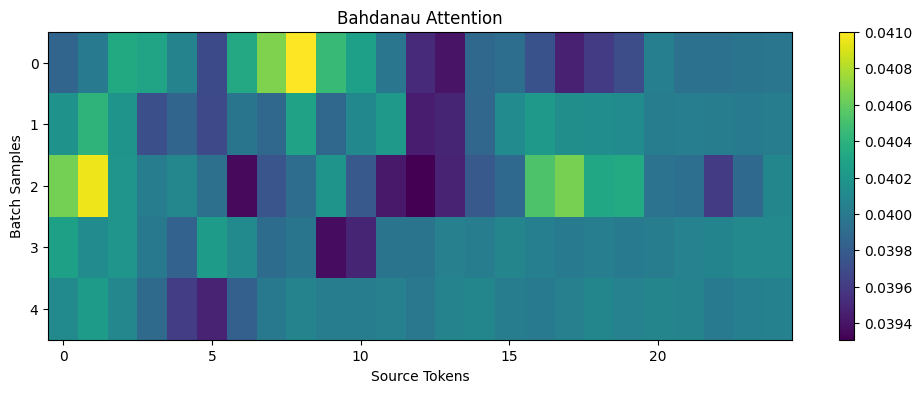

In [29]:

plt.figure(figsize=(12,4))

plt.imshow(
    attn[:5].detach().cpu().numpy(),
    aspect="auto"
)

plt.colorbar()

plt.xlabel("Source Tokens")

plt.ylabel("Batch Samples")

plt.title("Bahdanau Attention")

plt.show()

In [31]:
class Decoder(nn.Module):

    def __init__(
        self,
        output_dim,
        emb_dim,
        enc_hidden_dim,
        dec_hidden_dim,
        dropout,
        attention
    ):

        super().__init__()

        self.output_dim = output_dim
        self.attention = attention

        self.embedding = nn.Embedding(
            output_dim,
            emb_dim,
            padding_idx=TRG_PAD_IDX
        )

        self.rnn = nn.LSTM(
            input_size=(enc_hidden_dim*2) + emb_dim,
            hidden_size=dec_hidden_dim,
            num_layers=1
        )

        self.fc_out = nn.Linear(
            emb_dim + dec_hidden_dim + (enc_hidden_dim*2),
            output_dim
        )

        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        input,
        hidden,
        cell,
        encoder_outputs
    ):

        input = input.unsqueeze(0)

        embedded = self.dropout(
            self.embedding(input)
        )

        attention = self.attention(
            hidden,
            encoder_outputs
        )

        context = calculate_context(
            attention,
            encoder_outputs
        )

        rnn_input = torch.cat(
            (embedded, context),
            dim=2
        )

        output, (hidden, cell) = self.rnn(
            rnn_input,
            (hidden.unsqueeze(0), cell.unsqueeze(0))
        )

        prediction = self.fc_out(
            torch.cat(
                (
                    output.squeeze(0),
                    context.squeeze(0),
                    embedded.squeeze(0)
                ),
                dim=1
            )
        )

        return prediction, hidden.squeeze(0), cell.squeeze(0), attention

In [32]:

decoder = Decoder(
    OUTPUT_DIM,
    DEC_EMB_DIM,
    ENC_HIDDEN_DIM,
    DEC_HIDDEN_DIM,
    DEC_DROPOUT,
    attention
).to(device)

print(decoder)

Decoder(
  (attention): Attention(
    (attn): Linear(in_features=1536, out_features=512, bias=True)
    (v): Linear(in_features=512, out_features=1, bias=False)
  )
  (embedding): Embedding(7072, 256, padding_idx=0)
  (rnn): LSTM(1280, 512)
  (fc_out): Linear(in_features=1792, out_features=7072, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [33]:

src, trg = next(iter(train_loader))

src = src.to(device)

encoder_outputs, hidden, cell = encoder(src)

input_token = trg[0].to(device)

prediction, hidden, cell, attn = decoder(
    input_token,
    hidden,
    cell,
    encoder_outputs
)

print("Prediction :", prediction.shape)
print("Hidden :", hidden.shape)
print("Cell :", cell.shape)
print("Attention :", attn.shape)

Prediction : torch.Size([32, 7072])
Hidden : torch.Size([32, 512])
Cell : torch.Size([32, 512])
Attention : torch.Size([32, 25])


In [34]:

class Seq2Seq(nn.Module):

    def __init__(
        self,
        encoder,
        decoder,
        device
    ):

        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(
        self,
        src,
        trg,
        teacher_forcing_ratio=0.5
    ):

        batch_size = trg.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(
            trg_len,
            batch_size,
            trg_vocab_size
        ).to(self.device)

        encoder_outputs, hidden, cell = self.encoder(src)

        input = trg[0]

        for t in range(1, trg_len):

            output, hidden, cell, _ = self.decoder(
                input,
                hidden,
                cell,
                encoder_outputs
            )

            outputs[t] = output

            teacher_force = random.random() < teacher_forcing_ratio

            top1 = output.argmax(1)

            input = trg[t] if teacher_force else top1

        return outputs

In [35]:

model = Seq2Seq(
    encoder,
    decoder,
    device
).to(device)

print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(8379, 256, padding_idx=0)
    (dropout): Dropout(p=0.3, inplace=False)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.3, bidirectional=True)
    (fc_hidden): Linear(in_features=1024, out_features=512, bias=True)
    (fc_cell): Linear(in_features=1024, out_features=512, bias=True)
  )
  (decoder): Decoder(
    (attention): Attention(
      (attn): Linear(in_features=1536, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(7072, 256, padding_idx=0)
    (rnn): LSTM(1280, 512)
    (fc_out): Linear(in_features=1792, out_features=7072, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)


In [36]:

def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

print(f"Trainable Parameters : {count_parameters(model):,}")

Trainable Parameters : 31,600,288


In [37]:

criterion = nn.CrossEntropyLoss(
    ignore_index=TRG_PAD_IDX
)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [38]:

src, trg = next(iter(train_loader))

src = src.to(device)
trg = trg.to(device)

outputs = model(src, trg)

print(outputs.shape)

torch.Size([54, 32, 7072])


In [39]:

def train(model, loader, optimizer, criterion, clip=1):

    model.train()

    epoch_loss = 0

    for src, trg in tqdm(loader):

        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        output = model(src, trg)

        output_dim = output.shape[-1]

        output = output[1:].reshape(-1, output_dim)
        trg = trg[1:].reshape(-1)

        loss = criterion(output, trg)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            clip
        )

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [40]:

def evaluate(model, loader, criterion):

    model.eval()

    epoch_loss = 0

    with torch.no_grad():

        for src, trg in loader:

            src = src.to(device)
            trg = trg.to(device)

            output = model(
                src,
                trg,
                teacher_forcing_ratio=0
            )

            output_dim = output.shape[-1]

            output = output[1:].reshape(-1, output_dim)
            trg = trg[1:].reshape(-1)

            loss = criterion(output, trg)

            epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [41]:

N_EPOCHS = 15

best_valid_loss = float("inf")

train_losses = []
valid_losses = []

for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss = train(
        model,
        train_loader,
        optimizer,
        criterion
    )

    valid_loss = evaluate(
        model,
        dev_loader,
        criterion
    )

    end_time = time.time()

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    if valid_loss < best_valid_loss:

        best_valid_loss = valid_loss

        torch.save(
            model.state_dict(),
            "best_seq2seq_model.pt"
        )

    print(f"\nEpoch {epoch+1}/{N_EPOCHS}")

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Valid Loss : {valid_loss:.4f}")

    print(f"Time : {end_time-start_time:.2f} sec")

100%|██████████| 313/313 [01:08<00:00,  4.55it/s]



Epoch 1/15
Train Loss : 5.9859
Valid Loss : 5.5774
Time : 70.84 sec


100%|██████████| 313/313 [01:05<00:00,  4.74it/s]



Epoch 2/15
Train Loss : 5.3612
Valid Loss : 5.4725
Time : 67.74 sec


100%|██████████| 313/313 [01:03<00:00,  4.95it/s]


...


Epoch 13/15
Train Loss : 1.9633
Valid Loss : 6.0371
Time : 64.62 sec


100%|██████████| 313/313 [01:03<00:00,  4.94it/s]



Epoch 14/15
Train Loss : 1.8089
Valid Loss : 6.1654
Time : 65.16 sec


100%|██████████| 313/313 [01:03<00:00,  4.95it/s]



Epoch 15/15
Train Loss : 1.6603
Valid Loss : 6.2938
Time : 64.97 sec


In [42]:
model.load_state_dict(
    torch.load(
        "best_seq2seq_model.pt"
    )
)

print("Best model loaded.")

Best model loaded.


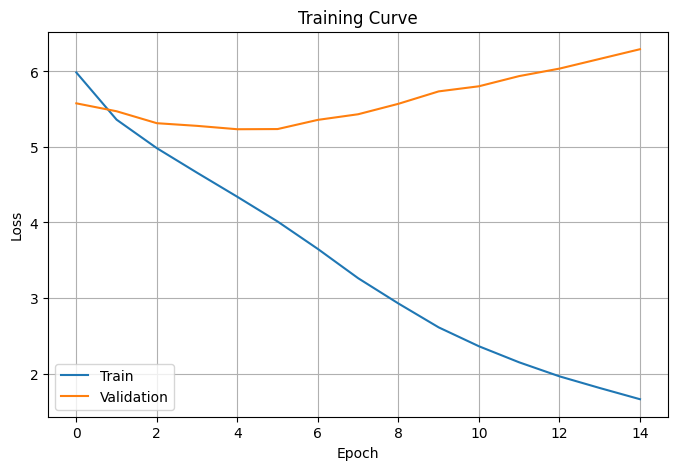

In [43]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")

plt.plot(valid_losses,label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Curve")

plt.legend()

plt.grid()

plt.show()

In [44]:
def translate_sentence(sentence, model, max_len=50):

    model.eval()

    tokens = tokenize(clean_text(sentence))

    src_indexes = [SRC_VOCAB["<sos>"]]

    for token in tokens:
        src_indexes.append(
            SRC_VOCAB.get(token, SRC_UNK_IDX)
        )

    src_indexes.append(SRC_EOS_IDX)

    src_tensor = torch.LongTensor(src_indexes).unsqueeze(1).to(device)

    with torch.no_grad():

        encoder_outputs, hidden, cell = model.encoder(src_tensor)

    trg_indexes = [TRG_SOS_IDX]

    attentions = []

    for _ in range(max_len):

        trg_tensor = torch.LongTensor(
            [trg_indexes[-1]]
        ).to(device)

        with torch.no_grad():

            output, hidden, cell, attention = model.decoder(
                trg_tensor,
                hidden,
                cell,
                encoder_outputs
            )

        pred_token = output.argmax(1).item()

        trg_indexes.append(pred_token)

        attentions.append(attention.cpu())

        if pred_token == TRG_EOS_IDX:
            break

    trg_tokens = [
        TRG_IDX2WORD[idx]
        for idx in trg_indexes[1:-1]
        if idx in TRG_IDX2WORD
    ]

    return trg_tokens

In [47]:
example = test_df.iloc[0]["Sentence_sa"]

prediction = translate_sentence(
    example,
    model
)

print("SOURCE:\n")
print(example)

print("\nPREDICTION:\n")
print(" ".join(prediction))

print("\nREFERENCE:\n")
print(test_df.iloc[0]["Sentence_en"])

SOURCE:

एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि साहाय्यं करोति।

PREDICTION:

the the <unk> <unk> the <unk> <unk> <unk>

REFERENCE:

eclipse also helps the programmer to find out errors.


In [49]:
predictions = []

references = []

start_time = time.time()

for i in tqdm(range(len(test_df))):

    src = test_df.iloc[i]["Sentence_sa"]

    pred = translate_sentence(src, model)

    predictions.append(" ".join(pred))

    references.append(test_df.iloc[i]["Sentence_en"])

end_time = time.time()

print("Inference Time :", end_time-start_time)

100%|██████████| 1000/1000 [00:16<00:00, 60.98it/s]

Inference Time : 16.402235984802246


In [51]:
for i in range(10):

    print("="*80)

    print("SOURCE :")
    print(test_df.iloc[i]["Sentence_sa"])

    print()

    print("REFERENCE :")
    print(references[i])

    print()

    print("PREDICTION :")
    print(predictions[i])

    print()

SOURCE :
एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि साहाय्यं करोति।

REFERENCE :
eclipse also helps the programmer to find out errors.

PREDICTION :
the the <unk> <unk> the <unk> <unk> <unk>

SOURCE :
विश्वासकारणादेव समभाषि मया वचः। इति यथा शास्त्रे लिखितं तथैवास्माभिरपि विश्वासजनकम् आत्मानं प्राप्य विश्वासः क्रियते तस्माच्च वचांसि भाष्यन्ते।

REFERENCE :
"we having the same spirit of faith, according as it is written, i believed, and therefore have i spoken; we also believe, and therefore speak;"

PREDICTION :
<unk> the <unk> of <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>

SOURCE :
तदा, तत्स्वयं ड्रैवर निमित्तम् अन्वेष्यति। अहं 'cancel' इत्यस्योपरि नुदामि।

REFERENCE :
then it will automatically begin searching for drivers. i will click on cancel.

PREDICTION :
click on the <unk> <unk> i click on the <unk> <unk>

SOURCE :
सर्वेभ्यः इटरेशन्-अर्थम्, iterator इतीदं प्रत्येकस्मै इण्डेक्स्-वेल्यू-इत्यस्मै सेट् क्रियते । 1,1 पश्च

In [52]:
from nltk.translate.bleu_score import corpus_bleu

references_bleu = [
    [ref.split()]
    for ref in references
]

predictions_bleu = [
    pred.split()
    for pred in predictions
]

bleu = corpus_bleu(
    references_bleu,
    predictions_bleu
)

print(f"BLEU Score : {bleu:.4f}")

BLEU Score : 0.0337


In [53]:
from bert_score import score

P, R, F1 = score(
    predictions,
    references,
    lang="en",
    verbose=True
)

print()

print("BERTScore Precision :", P.mean().item())

print("BERTScore Recall :", R.mean().item())

print("BERTScore F1 :", F1.mean().item())

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/28 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 9.31 seconds, 107.41 sentences/sec

BERTScore Precision : 0.7820451855659485
BERTScore Recall : 0.8356317281723022
BERTScore F1 : 0.8075615167617798


In [54]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total Parameters :", total_params)

print("Trainable Parameters :", trainable_params)

Total Parameters : 31600288
Trainable Parameters : 31600288


In [56]:
submission = pd.DataFrame()

submission["Source_id"] = test_df["Source_id"]

submission["Translation"] = predictions

submission.to_csv(
    "submission.csv",
    index=False
)

print(submission.head())

print()

print("submission.csv saved successfully.")

   Source_id                                        Translation
0          1          the the <unk> <unk> the <unk> <unk> <unk>
1          2  <unk> the <unk> of <unk> <unk> <unk> <unk> <un...
2          3  click on the <unk> <unk> i click on the <unk> ...
3          4  the <unk> is a <unk> <unk> <unk> <unk> <unk> <...
4          5  "and the the <unk> <unk> <unk> <unk> <unk> <un...

submission.csv saved successfully.


In [58]:
results = pd.DataFrame({

    "Source":test_df["Sentence_sa"],

    "Reference":references,

    "Prediction":predictions

})

results.to_csv(
    "translation_results.csv",
    index=False
)

print(results.head())

                                              Source  \
0  एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि...   
1  विश्वासकारणादेव समभाषि मया वचः। इति यथा शास्त्...   
2  तदा, तत्स्वयं ड्रैवर निमित्तम् अन्वेष्यति। अहं...   
3  सर्वेभ्यः इटरेशन्-अर्थम्, iterator इतीदं प्रत्...   
4  अपरं द्वितीयमुद्रायां तेन मोचितायां द्वितीयस्य...   

                                           Reference  \
0  eclipse also helps the programmer to find out ...   
1  "we having the same spirit of faith, according...   
2  then it will automatically begin searching for...   
3  the iterator will be set to each of the indice...   
4  "and when he had opened the second seal, i hea...   

                                          Prediction  
0          the the <unk> <unk> the <unk> <unk> <unk>  
1  <unk> the <unk> of <unk> <unk> <unk> <unk> <un...  
2  click on the <unk> <unk> i click on the <unk> ...  
3  the <unk> is a <unk> <unk> <unk> <unk> <unk> <...  
4  "and the the <unk> <unk> <unk> <unk> <unk> <un..

In [59]:
print("="*70)

print("MODEL SUMMARY")

print("="*70)

print("Trainable Parameters :", trainable_params)

print()

print("BLEU Score :", bleu)

print()

print("BERTScore F1 :", F1.mean().item())

print()

print("Inference Time :", end_time-start_time)

print()

print("Average Time Per Sentence :",
      (end_time-start_time)/len(test_df))

print()

print("Submission File : submission.csv")

print()

print("Prediction File : translation_results.csv")

print("="*70)

MODEL SUMMARY
Trainable Parameters : 31600288

BLEU Score : 0.033714672721435954

BERTScore F1 : 0.8075615167617798

Inference Time : 16.402235984802246

Average Time Per Sentence : 0.016402235984802248

Submission File : submission.csv

Prediction File : translation_results.csv
